In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, load_iris
from sklearn.naive_bayes import GaussianNB as SklearnNB
from sklearn.metrics import accuracy_score, classification_report


# THE MATH BEHIND NAIVE BAYES


# Based on Bayes' Theorem:
#   P(class | features) = P(features | class) * P(class) / P(features)

# "Naive" assumption: all features are independent given the class.
#   P(x1, x2, ..., xn | class) = P(x1|class) * P(x2|class) * ... * P(xn|class)
#
# For Gaussian Naive Bayes, each P(xi | class) follows a normal distribution:
#   P(xi | class) = (1 / sqrt(2*pi*sigma^2)) * exp(-(xi - mu)^2 / (2*sigma^2))
#
# Training: for each class, compute mean and variance of each feature.
# Prediction: for each class, compute the posterior probability.
#             Pick the class with highest probability.

In [6]:
class NaiveBayesScratch:

    def __init__(self):
        self.classes = None 
        self.class_priors = {}
        self.class_means = {}
        self.class_vars = {}

    def fit(self, X, y):
        self.classes = np.unique(y)

        for c in self.classes:
            c_key = int(c)  # Ensure standard Python integer key
            X_c = X[y == c]
            self.class_priors[c_key] = len(X_c) / len(X)
            self.class_means[c_key] = X_c.mean(axis=0)
            self.class_vars[c_key] = X_c.var(axis=0) + 1e-9 
            
        return self  

    def _gaussian_pdf(self, x, mean, var):
        """Calculating the Gaussian Probability Density"""
        return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x - mean) ** 2 / (2 * var))

    def _predict_single(self, x):
        posteriors = {}

        for c in self.classes:
            c_key = int(c)
            prior = np.log(self.class_priors[c_key])

            # Add log-likelihoods for all features
            pdf_vals = self._gaussian_pdf(x, self.class_means[c_key], self.class_vars[c_key])
            likelihood = np.sum(np.log(pdf_vals + 1e-15)) 

            posteriors[c_key] = prior + likelihood 

        return max(posteriors, key=posteriors.get)  

    def predict(self, X):
        return np.array([self._predict_single(x) for x in X])

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

In [7]:
np.random.seed(42)

X, y = make_classification(
    n_samples = 500, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1,
    random_state=42
)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = NaiveBayesScratch()
model.fit(X_train, y_train)

print(f"Train accuracy: {model.score(X_train, y_train) * 100:.1f}%")
print(f"Test accuracy: {model.score(X_test, y_test) * 100:.1f}%")

Train accuracy: 87.5%
Test accuracy: 88.0%


In [8]:
print(f"\nLearned parameters:")
for c in model.classes:
    print(f"  Class {c}: prior={model.class_priors[c]:.3f}, means={np.round(model.class_means[c], 3)}")


Learned parameters:
  Class 0: prior=0.505, means=[ 0.98  -1.016]
  Class 1: prior=0.495, means=[1.059 1.021]


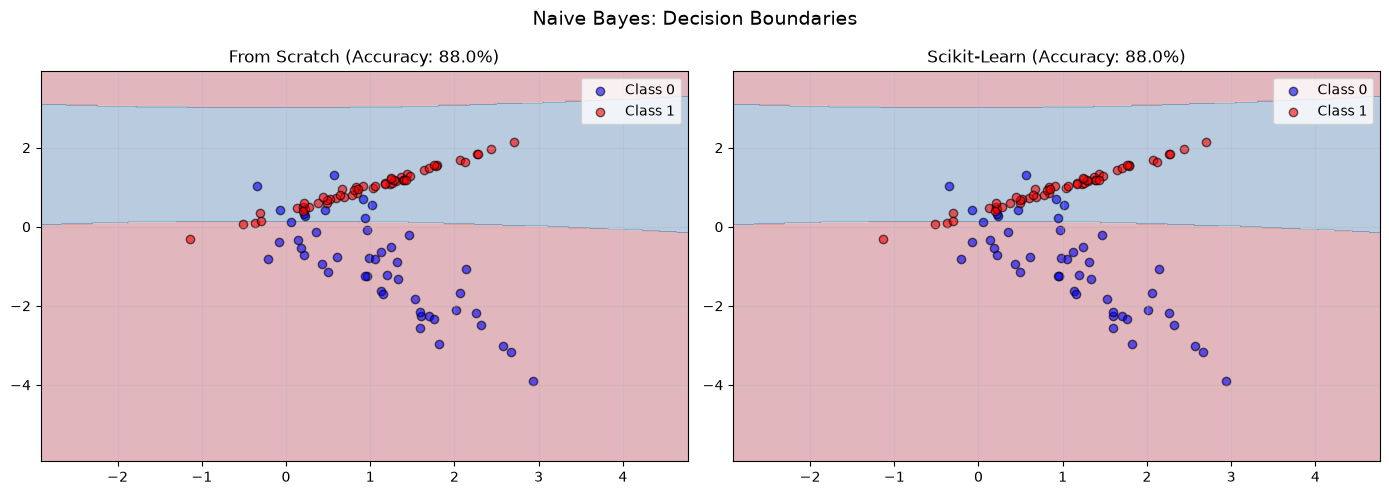

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                      np.arange(y_min, y_max, 0.02))

# From scratch
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
axes[0].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
                c='blue', label='Class 0', alpha=0.6, edgecolors='k')
axes[0].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
                c='red', label='Class 1', alpha=0.6, edgecolors='k')
axes[0].set_title(f'From Scratch (Accuracy: {model.score(X_test, y_test)*100:.1f}%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scikit-learn
sklearn_model = SklearnNB()
sklearn_model.fit(X_train, y_train)
Z_sk = sklearn_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z_sk, alpha=0.3, cmap='RdBu')
axes[1].scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1],
                c='blue', label='Class 0', alpha=0.6, edgecolors='k')
axes[1].scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1],
                c='red', label='Class 1', alpha=0.6, edgecolors='k')
axes[1].set_title(f'Scikit-Learn (Accuracy: {sklearn_model.score(X_test, y_test)*100:.1f}%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Naive Bayes: Decision Boundaries', fontsize=14)
plt.tight_layout()
plt.savefig('naive_bayes_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

idx = np.random.permutation(len(X_iris))
X_iris, y_iris = X_iris[idx], y_iris[idx]
split = int(0.8 * len(X_iris))

X_tr, X_te = X_iris[:split], X_iris[split:]
y_tr, y_te = y_iris[:split], y_iris[split:]

model_iris = NaiveBayesScratch()
model_iris.fit(X_tr, y_tr)

sklearn_iris = SklearnNB()
sklearn_iris.fit(X_tr, y_tr)

print(f"{'Metric':<20} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*50}")
print(f"{'Train Accuracy':<20} {model_iris.score(X_tr, y_tr)*100:>14.1f}% {sklearn_iris.score(X_tr, y_tr)*100:>14.1f}%")
print(f"{'Test Accuracy':<20} {model_iris.score(X_te, y_te)*100:>14.1f}% {sklearn_iris.score(X_te, y_te)*100:>14.1f}%")

Metric                  From Scratch    Scikit-Learn
--------------------------------------------------
Train Accuracy                 95.8%           95.8%
Test Accuracy                  93.3%           93.3%


print("""
============================================================
NAIVE BAYES FROM SCRATCH — COMPLETE
============================================================

What was built:
  - NaiveBayesScratch class using only NumPy
  - Gaussian probability density function
  - Class prior computation
  - Log-posterior calculation (prevents numerical underflow)
  - fit(), predict(), score() methods

Key concepts:
  - Bayes theorem: P(class|data) = P(data|class) * P(class) / P(data)
  - "Naive" = features are assumed independent
  - Training is just calculating means and variances
  - Very fast: no gradient descent, no iterations
  - Works surprisingly well for text classification and spam detection

Verified against scikit-learn: results match.
============================================================

### ALL 6 MODELS FROM SCRATCH COMPLETE:
  1. Linear Regression     (regression, gradient descent)
  2. Logistic Regression   (classification, sigmoid + gradient descent)
  3. Decision Tree         (classification, recursive splitting)
  4. K-Nearest Neighbors   (classification, distance-based)
  5. K-Means               (clustering, unsupervised)
  6. Naive Bayes           (classification, probabilistic)
